<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# CMSE 801 - Day 24
## Using random numbers for numerical solutions and optimization
### Application: The Traveling Salesperson Problem
#### November 25, 2024

## General Course Announcements

* Final version of your project notebook is due **December 1 by 11:59pm**.
    * We will assign presentation days on **today** using a random number generator.
        * Some of our presentations will extend beyond the normal class ending time, if you cannot stick around past 9:50am, please let me know.
    * Your presentation will be **strictly limited to 4 minutes**.
    * You will be getting project credit for observing and rating your peers, so you are expected to attend both presentation days.
* You can continue to work on your slides after that deadline and up until you present.
* Homework 5 is due **Friday, December 6, by 11:59pm**.

## Let's assign presentation days!

In [1]:
import numpy as np
import pandas as pd

roster = pd.read_csv("CMSE801-FS24.csv")

In [2]:
all_names = []
for i in range(len(roster)):
    all_names.append('%s %s' %(roster['First Name'].loc[i],roster['Last Name'].loc[i]))
print(all_names)

['Lee Ackerson', 'Hussain Aljafer', 'Yusuf Basmaci', 'Nyla Blagrove', 'Derek Bowman', 'Randy Burks', 'Spencer Combs', 'David Creamer', 'Atoshi Das', 'Aditya Dhaka', 'Megha Dinesh', 'Ardeshir Fadaei', 'John Grivins', 'Dillon Haller', 'Madison Honore', 'Andrew Huang', 'Sanjida Islam', 'Annie Islam', 'Jeonga Kang', 'Faizan Lali', 'Joey Larabee', 'Derek Luzano', 'Deil Manliclic', 'Jeet Mitra', 'Gerardo Morales Torres', 'Scholasticah Nyamao', 'Victor Pietono', 'Diego Piraquive Gomez', 'Rachael Pyram', 'Alex Reynolds', 'Gui Roma Moura Martins', 'Surbhi Schillinger', 'Claire Schregardus', 'Shanu Shameem', 'Blake Smerigan', 'Ryan Smith', 'Sophie Sunderland', 'Shivani Verma', 'Sajjad Vosoughinia', 'Harris Vousoura', 'Evelyn Wang', 'Muhammad Zafar']


In [3]:
pre_excused_day1 = ['Jeet Mitra','Diego Piraquive Gomez','Harris Vousoura']
pre_excused_day2 = []

In [4]:
# Remove anyone who was pre-excused from Day 1 or Day 2
# (since they need to be assigned by hand)
for s in (pre_excused_day1 + pre_excused_day2):
    if s in all_names:
        all_names.remove(s)
        
#### Choose who will present on the Day 1 ####

# Define an array for storing presenter names
day1 = np.array([])

# Add in anyone excused from Day 2 to ensure they present on Day 1
day1 = np.append(day1,pre_excused_day2)
    
# Now we pick 24 people to present on Day 1
pick_Day1 = np.random.choice(all_names, 24, replace=False)

# Append the picks to the first array
day1 = np.append(day1,pick_Day1)

# Shuffle the students to determine presentation order
np.random.shuffle(day1)

# Print and store the results for Day 1
print("The following students will present on Day 1 (December 2):\n")
day1_with_order = []
count = 0
for i,student in enumerate(day1):
    count += 1
    print("%i" %(count),student)
    day1_with_order.append("%i %s" %(count,student))
    
#### Choose who will present on Day 2 ###

# Assign all the remaining students to Day 2:
day2 = []
for student in all_names:
    if student not in day1:
        day2.append(student)
        
# Add in anyone excused from Day 1
day2 = np.append(day2,pre_excused_day1)

# Shuffle the student determine the presentation order
np.random.shuffle(day2)

# Print and store the results for Day 2
print("\nThe following students will present on Day 2 (December 4):\n")
day2_with_order = []
count = 0
for i,student in enumerate(day2):
    count += 1
    print("%i" %(count),student)
    day2_with_order.append("%i %s" %(count,student))
        
# Check for potential duplicates (in case a mistake was made)
for student in day1:
    if student in day2:
        print(student)

The following students will present on Day 1 (December 2):

1 Megha Dinesh
2 Sanjida Islam
3 Joey Larabee
4 Sajjad Vosoughinia
5 Muhammad Zafar
6 Derek Bowman
7 Gui Roma Moura Martins
8 Victor Pietono
9 Scholasticah Nyamao
10 Hussain Aljafer
11 David Creamer
12 Lee Ackerson
13 Evelyn Wang
14 Andrew Huang
15 Madison Honore
16 Faizan Lali
17 Shivani Verma
18 Randy Burks
19 Ryan Smith
20 Atoshi Das
21 Surbhi Schillinger
22 Shanu Shameem
23 Derek Luzano
24 Nyla Blagrove

The following students will present on Day 2 (December 4):

1 Gerardo Morales Torres
2 Aditya Dhaka
3 Ardeshir Fadaei
4 Dillon Haller
5 Spencer Combs
6 Rachael Pyram
7 Diego Piraquive Gomez
8 Harris Vousoura
9 Jeonga Kang
10 John Grivins
11 Deil Manliclic
12 Alex Reynolds
13 Jeet Mitra
14 Claire Schregardus
15 Annie Islam
16 Yusuf Basmaci
17 Blake Smerigan
18 Sophie Sunderland


In [5]:
# Save the results to a file
f = open("CMSE801-presentations-FS24.txt", "w+")

f.write("The following students will present on Day 1 (December 2):\n\n")
for s in day1_with_order:
    f.write("%s \n" %s)
f.write("\n")

f.write("=====================================================================\n")

f.write("The following students will present on Day 2 (December 4):\n\n")
for s in day2_with_order:
    f.write("%s \n" %s)
f.write("\n")
        
f.close()

## Questions/comments from Day 24 PCA

* Some struggles with the animation code
* Some challenges with the distance calculation and then feeding that into the final animation

## Solving problems with random numbers

* Random numbers can be used to find solutions to problems that would either take too long to solve exactly, or have no exact solutions.
* The traveling salesperson problem is a good example of this -- testing every single possible route can take a _very long time_.
    * For $20$ cities, this would require $2,432,902,008,176,640,000$ (approximately $2.4 \times 10^{18}$) tests - if you could test one combination per microsecond ($10^{-6}$ s) it would take approximately 76,000 years!
* Using random numbers we can try to find a "good enough" solution.

## Using random numbers to evaluate integrals

Let's find the solution to this integral, numerically: $$y = \sqrt{1 - x^2}$$

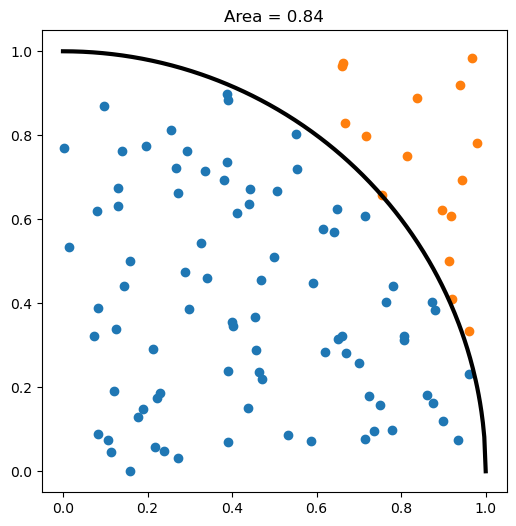

Area = 0.84
Real area = 0.7853981633974483


<Figure size 600x600 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import random
import numpy as np
from IPython.display import display, clear_output
import time
import random

# Set up the figure
fig = plt.figure(figsize=(6,6))

# How many points will we drop on the graph?
npoints = 100

# Set up variables for keeping track of points
is_in = 0
is_out = 0
x_in = []
y_in = []
x_out = []
y_out = []

for i in range(npoints):
    # Draw a point at random
    x = random.random()
    y = random.random()
    
    # Check is the point is inside or outside the curve
    if y < np.sqrt(1-x**2):
        is_in += 1
        x_in.append(x)
        y_in.append(y)
    else:
        is_out += 1
        x_out.append(x)
        y_out.append(y)
    
    # Plot the point
    plt.scatter(x_in,y_in)
    plt.scatter(x_out,y_out)
    
    x = np.linspace(0,1,300)
    y = np.sqrt(1-x**2)
    # Plot the curve
    plt.plot(x,y,lw=3,c='k')
    
    # Calculate estimated value of the integral
    plt.title("Area = %0.2f" %(is_in/npoints))
    
    time.sleep(0.1)  
    clear_output(wait = True)
    display(fig)            # Reset display
    fig.clear()

print("Area =", is_in/npoints)
print("Real area =", np.pi/4.0)

## Setting up "cities" for the salesperson

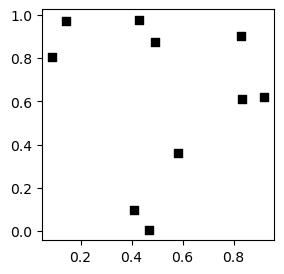

In [7]:
def create_cities(n_city):
    x_loc = np.random.random(n_city)
    y_loc = np.random.random(n_city)
    return x_loc,y_loc

n_city = 10
x,y = create_cities(n_city)
plt.figure(figsize=(3,3))
plt.scatter(x,y,marker="s",c="k");

## Create a distance matrix

In [8]:
def calculate_distances(x_loc, y_loc):
    D = np.zeros((len(x_loc), len(y_loc)))
    for i in range(D.shape[0]):
        this_x = x_loc[i]
        this_y = y_loc[i]
        for j in range(D.shape[1]):
             D[i,j] = np.sqrt((x_loc[j]-this_x)**2 + (y_loc[j]-this_y)**2)
    return D

n_city = 5
x,y = create_cities(n_city)
D = calculate_distances(x,y)
print(D)

[[0.         0.44300814 0.87377864 0.90934775 0.46572498]
 [0.44300814 0.         0.75585721 0.53502831 0.30818643]
 [0.87377864 0.75585721 0.         0.5526311  0.46608947]
 [0.90934775 0.53502831 0.5526311  0.         0.47792432]
 [0.46572498 0.30818643 0.46608947 0.47792432 0.        ]]


## Wander through the cities in order

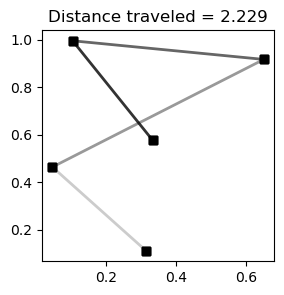

<Figure size 300x300 with 0 Axes>

In [9]:
fig = plt.figure(figsize=(3,3));
total_distance = 0
for i in range(n_city-1):
    plt.scatter(x,y,marker="s",c="k");
    plt.plot([x[i],x[i+1]], [y[i],y[i+1]],
             alpha=(i+1)/(n_city),lw=2,color="k");
    total_distance += D[i,i+1]
    plt.title("Distance traveled = %0.3f" %total_distance)
    time.sleep(1.0)  
    clear_output(wait = True)
    display(fig) # Reset display
fig.clear()

## Goals for today
* Use randomness to "guess" your ways to shortest route for a traveling salesperson
* Visualize your progress towards finding the "best" solution (within computational reason)

## Looking forward - Day 25 PCA: Revisiting fitting models to data

* Remind ourselves what it means to find a goodness of fit
* Explore the "chi-squared" method of determine goodness of fit
* Perform a "grid search" to find best fit parameters
